# 02 — Feature Engineering

Feature chỉ được tính từ thông tin có sẵn tại hoặc trước khi đóng cửa ngày `t`. Ranh giới train/validation/holdout theo thời gian được tạo trước khi fit bất kỳ scaler nào. `date` được giữ để audit và không bao giờ đi vào production matrix.

In [1]:
import json
import os
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MPL_CONFIG = ROOT / ".matplotlib"
MPL_CONFIG.mkdir(exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(MPL_CONFIG)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
# Run minh hoạ mặc định dùng VIC; pipeline nhận ticker khác qua config/CLI.
DATA_PATH = ROOT / "data" / "raw" / "VIC_VN.csv"
REPORT_DIR = ROOT / "evaluation"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)


FEATURES = [
    "return_1d", "return_5d", "volatility_10", "volatility_20",
    "volume_z_20", "rsi_14", "macd_scaled", "price_ma20", "price_ma50",
]
TARGET = "target_return_5d"

def build_frame(raw: pd.DataFrame) -> pd.DataFrame:
    df = raw.copy().sort_values("date").drop_duplicates("date").reset_index(drop=True)
    close = pd.to_numeric(df["close"], errors="coerce")
    volume = pd.to_numeric(df["volume"], errors="coerce")
    returns = np.log(close / close.shift(1))
    delta = close.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / 14, adjust=False).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / 14, adjust=False).mean()
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd = ema12 - ema26
    df["return_1d"] = returns
    df["return_5d"] = np.log(close / close.shift(5))
    df["volatility_10"] = returns.rolling(10).std()
    df["volatility_20"] = returns.rolling(20).std()
    df["volume_z_20"] = (volume - volume.rolling(20).mean()) / volume.rolling(20).std()
    df["rsi_14"] = (100 - 100 / (1 + gain / loss.replace(0, np.nan))) / 100
    df["macd_scaled"] = macd / close
    df["price_ma20"] = close / close.rolling(20).mean() - 1
    df["price_ma50"] = close / close.rolling(50).mean() - 1
    df[TARGET] = np.log(close.shift(-5) / close)
    return df.replace([np.inf, -np.inf], np.nan)

In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
frame = build_frame(raw).dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
n = len(frame)
train_end, validation_end = int(n * .60), int(n * .80)
train = frame.iloc[:train_end].copy()
validation = frame.iloc[train_end:validation_end].copy()
holdout = frame.iloc[validation_end:].copy()
split_summary = pd.DataFrame({
    "rows": [len(train), len(validation), len(holdout)],
    "start": [x.date.min().date() for x in (train, validation, holdout)],
    "end": [x.date.max().date() for x in (train, validation, holdout)],
}, index=["train", "validation", "holdout"])
split_summary

,rows,start,end
train,1315,2018-03-09,2023-03-29
validation,438,2023-03-30,2024-12-02
holdout,439,2024-12-03,2026-08-07


In [3]:
corr = train[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
matrix_corr = train[FEATURES].corr().abs()
high_pairs = [
    (a, b, round(float(matrix_corr.loc[a, b]), 3))
    for i, a in enumerate(FEATURES)
    for b in FEATURES[i + 1:]
    if matrix_corr.loc[a, b] > .90
]
print("Tương quan feature-target (chỉ trên train):")
display(corr.to_frame("correlation"))
print("Các cặp vượt |0,90|:", high_pairs)

Tương quan feature-target (chỉ trên train):


,correlation
macd_scaled,-0.074613
volume_z_20,0.067319
volatility_10,0.055190
price_ma50,-0.042492
price_ma20,-0.030691
return_1d,0.023735
return_5d,0.017210
volatility_20,0.015243
rsi_14,0.007199


Các cặp vượt |0,90|: [('macd_scaled', 'price_ma50', 0.948)]


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(train[FEATURES])
scaled_train = scaler.transform(train[FEATURES])
assert np.isfinite(scaled_train).all()
feature_contract = {
    "production_features": FEATURES,
    "audit_only": ["date", "open", "high", "low", "close", "volume"],
    "excluded": [TARGET, "ticker/id", "giá đóng cửa tương lai"],
    "sequence_length": 20,
    "train_only_preprocessing": True,
    "split_rows": {"train": len(train), "validation": len(validation), "holdout": len(holdout)},
}
print(json.dumps(feature_contract, indent=2))

{
  "production_features": [
    "return_1d",
    "return_5d",
    "volatility_10",
    "volatility_20",
    "volume_z_20",
    "rsi_14",
    "macd_scaled",
    "price_ma20",
    "price_ma50"
  ],
  "audit_only": [
    "date",
    "open",
    "high",
    "low",
    "close",
    "volume"
  ],
  "excluded": [
    "target_return_5d",
    "ticker/id",
    "gi\u00e1 \u0111\u00f3ng c\u1eeda t\u01b0\u01a1ng lai"
  ],
  "sequence_length": 20,
  "train_only_preprocessing": true,
  "split_rows": {
    "train": 1315,
    "validation": 438,
    "holdout": 439
  }
}


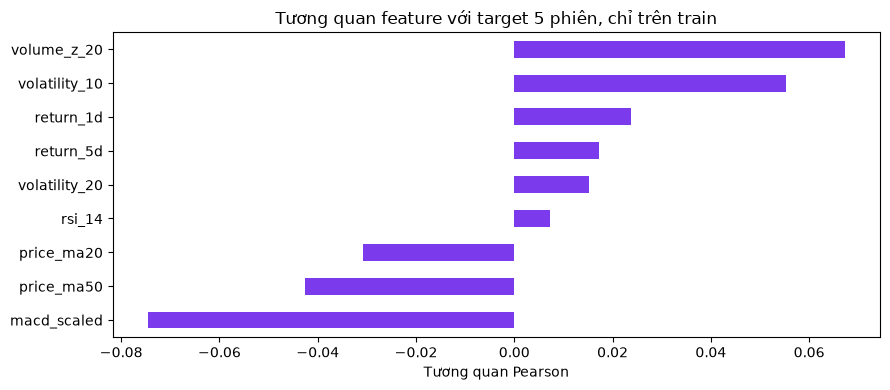

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
corr.sort_values().plot.barh(ax=ax, color="#7c3aed")
ax.set(title="Tương quan feature với target 5 phiên, chỉ trên train", xlabel="Tương quan Pearson")
plt.tight_layout()
plt.show()